# Model training of **Coffee Shop Sales** Dataset using **Logistic regression**

In [1]:
#importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
from google.colab import files
uploaded = files.upload()

Saving coffee_shop_revenue.csv to coffee_shop_revenue (1).csv


In [3]:
df = pd.read_csv("coffee_shop_revenue.csv")

In [4]:
df

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42
...,...,...,...,...,...,...,...
1995,372,6.41,11,4,466.11,913,2816.85
1996,105,3.01,11,7,12.62,235,337.97
1997,89,5.28,16,9,376.64,310,951.34
1998,403,9.41,7,12,452.49,577,4266.21


**Data Exploration:** Exploring the dataset to understand its structure, data types, statistical summary, and identify any missing values.

In [5]:
df.head()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42


In [6]:
df.tail()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
1995,372,6.41,11,4,466.11,913,2816.85
1996,105,3.01,11,7,12.62,235,337.97
1997,89,5.28,16,9,376.64,310,951.34
1998,403,9.41,7,12,452.49,577,4266.21
1999,89,6.88,13,14,78.46,322,914.24


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB


In [8]:
df.describe()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,274.296000,6.261215,11.667000,7.947000,252.614160,534.893500,1917.325940
std,129.441933,2.175832,3.438608,3.742218,141.136004,271.662295,976.202746
min,50.000000,2.500000,6.000000,2.000000,10.120000,50.000000,-58.950000
25%,164.000000,4.410000,9.000000,5.000000,130.125000,302.000000,1140.085000
50%,275.000000,6.300000,12.000000,8.000000,250.995000,540.000000,1770.775000
75%,386.000000,8.120000,15.000000,11.000000,375.352500,767.000000,2530.455000
max,499.000000,10.000000,17.000000,14.000000,499.740000,999.000000,5114.600000


In [9]:
df.isnull().sum()

,0
Number_of_Customers_Per_Day,0
Average_Order_Value,0
Operating_Hours_Per_Day,0
Number_of_Employees,0
Marketing_Spend_Per_Day,0
Location_Foot_Traffic,0
Daily_Revenue,0


**Data Exploration:** Exploring the dataset to understand its structure, data types, statistical summary, and identify any missing values.

In [10]:
# Create binary target using median revenue
median = df["Daily_Revenue"].median()

df["Revenue_Category"] = (df["Daily_Revenue"] >= median).astype(int)

In [11]:
# Check the updated dataset
df.head()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue,Revenue_Category
0,152,6.74,14,4,106.62,97,1547.81,0
1,485,4.50,12,8,57.83,744,2084.68,1
2,398,9.09,6,6,91.76,636,3118.39,1
3,320,8.48,17,4,462.63,770,2912.20,1
4,156,7.44,17,2,412.52,232,1663.42,0


In [12]:
# Calculate correlation between features
corr = df.corr(numeric_only=True)

corr

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue,Revenue_Category
Number_of_Customers_Per_Day,1.000000,-0.014647,0.000122,0.000346,0.027184,-0.000880,0.736461,0.622728
Average_Order_Value,-0.014647,1.000000,-0.017125,0.011484,0.018782,0.018151,0.535694,0.442316
Operating_Hours_Per_Day,0.000122,-0.017125,1.000000,-0.030451,0.019247,0.014422,-0.005323,-0.014835
Number_of_Employees,0.000346,0.011484,-0.030451,1.000000,0.026535,-0.041881,0.003295,-0.028867
Marketing_Spend_Per_Day,0.027184,0.018782,0.019247,0.026535,1.000000,-0.012562,0.254812,0.191712
Location_Foot_Traffic,-0.000880,0.018151,0.014422,-0.041881,-0.012562,1.000000,0.013469,0.015403
Daily_Revenue,0.736461,0.535694,-0.005323,0.003295,0.254812,0.013469,1.000000,0.804041
Revenue_Category,0.622728,0.442316,-0.014835,-0.028867,0.191712,0.015403,0.804041,1.000000


In [13]:
#importing seaborn library
import seaborn as sns

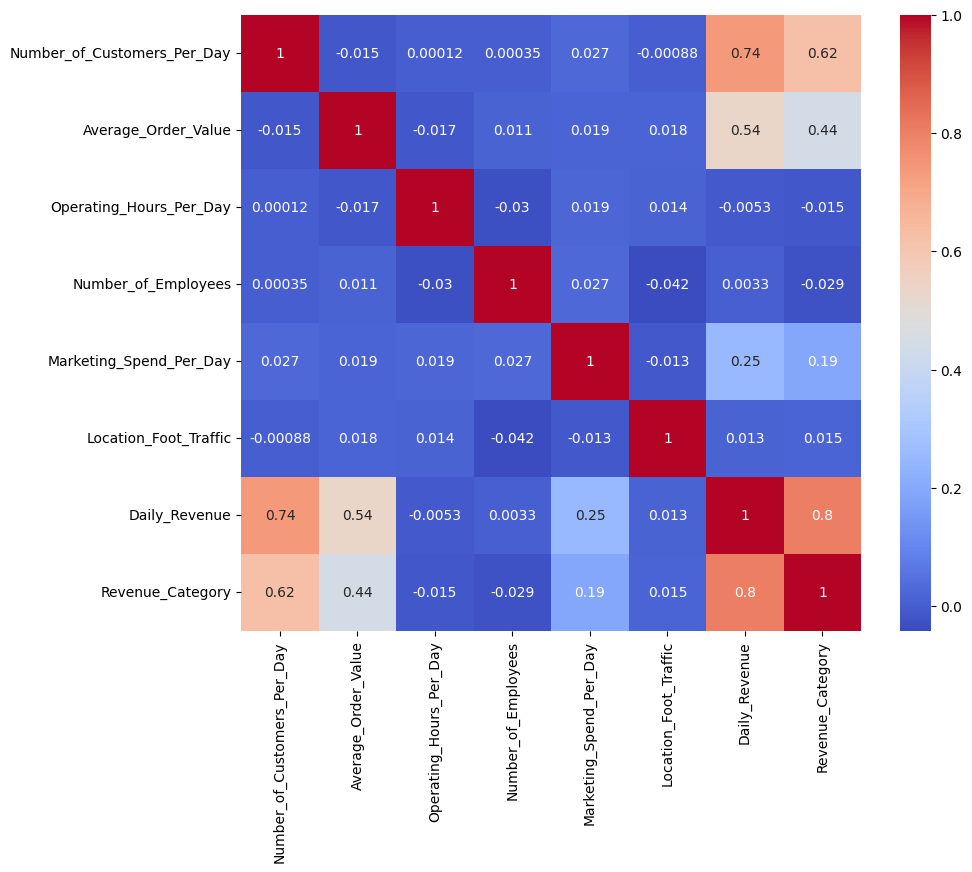

In [14]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [15]:
# Divide the data into X and Y
X = df.drop(["Daily_Revenue", "Revenue_Category"], axis=1)
y = df["Revenue_Category"]

In [16]:
#display features
X.head()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic
0,152,6.74,14,4,106.62,97
1,485,4.50,12,8,57.83,744
2,398,9.09,6,6,91.76,636
3,320,8.48,17,4,462.63,770
4,156,7.44,17,2,412.52,232


In [17]:
#display target
y.head()

,Revenue_Category
0,0
1,1
2,1
3,1
4,0


In [18]:
# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
X_train

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic
968,352,4.02,17,7,285.32,835
240,344,4.44,12,10,454.80,109
819,129,8.80,9,6,52.20,275
692,417,7.42,9,2,383.35,815
420,329,4.56,12,6,261.01,221
...,...,...,...,...,...,...
1130,74,7.39,17,7,317.70,982
1294,286,5.05,15,2,279.84,599
860,227,4.37,8,2,240.64,142
1459,467,8.11,13,10,461.89,498


In [20]:
X_test

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic
1860,463,7.19,6,9,214.55,558
353,148,7.15,7,12,184.71,244
1333,460,3.48,16,10,456.30,254
905,331,6.58,14,14,77.81,562
1289,127,9.88,8,5,434.17,440
...,...,...,...,...,...,...
965,450,4.58,12,4,116.71,495
1284,262,9.67,8,14,132.74,63
1739,157,4.05,17,12,197.93,444
261,102,7.48,15,13,466.81,477


In [21]:
y_train

,Revenue_Category
968,1
240,1
819,0
692,1
420,0
...,...
1130,0
1294,0
860,0
1459,1


In [22]:
y_test

,Revenue_Category
1860,1
353,0
1333,1
905,1
1289,1
...,...
965,0
1284,1
1739,0
261,0


**Creating and Training the Model:** Initializing the Logistic Regression model and training it using the training dataset.

In [23]:
# Create the Logistic Regression model
model = LogisticRegression()

In [24]:
# Train the model
model.fit(X_train, y_train)

LogisticRegression()

In [25]:
#predict the test data
y_pred = model.predict(X_test)

In [26]:
y_pred

array([1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,

**Model Evaluation:** Evaluating the model's performance using accuracy score, confusion matrix, and classification report.

In [27]:
model.score(X_train,y_train)

0.91125

In [28]:
model.score(X_test,y_test)

0.92

In [29]:
# Calculate the accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.92


In [30]:
# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[180  15]
 [ 17 188]]


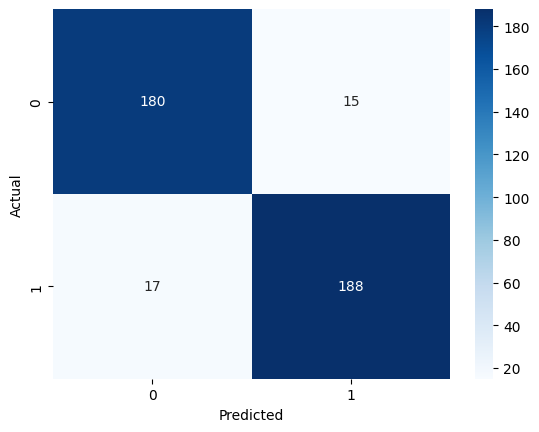

In [31]:
# Visualize the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Conclusion:** The Logistic Regression model was successfully trained to classify coffee shop revenue into high and low revenue categories. The model showed good performance and was evaluated using training score, testing score, and accuracy score.